In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.io import savemat
import math
from loading_real_wave_noise import loading_real_wave_noise
from Reading_path_test import loading_paths_from_MAT
from Control_filter_selection_pre_now import Control_filter_selection_pre_now
from Control_filter_selection import Control_filter_selection
from Fixed_filter_noise_cancellation_subfilters import Fixed_filter_controller
from Disturbance_generation import Disturbance_generation_from_real_noise
from FxLMS_algorithm import FxLMS, train_fxlms_algorithm

print(torch.cuda.is_available())

True


In [2]:
# Loading real noises
mdict = {}
fs = 16000
StepSize = 0.0001
sound_name = 'Helicopter'
waveform, resample_rate = loading_real_wave_noise(folde_name='Real Noise Examples/', sound_name=sound_name+'.wav')

In [3]:
waveform = waveform[0]
waveform = waveform.unsqueeze(0)

In [66]:
delay = 0

In [67]:
# Loading path
subfolder = "Secondary_path_delay_" + str(delay) + "samples"
# subfolder = "Dongyuan"
Pri_path, Secon_path = loading_paths_from_MAT(folder='Pz and Sz', subfolder=subfolder, Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
# Dis: disturbance (cotrolled noise)， Fx: fixed-x signal, Re: repeated waveform (primary_noise) Repetition=Repet+1

In [68]:
print(waveform.shape)
print(Dis.shape)
print(Fx.shape)
print(Re.shape)

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

torch.Size([1, 160000])
torch.Size([160000])
torch.Size([160000])
torch.Size([160000])


In [69]:
def additional_noise(signal, snr_db):
    signal_power = signal.square().mean()
    additional_noise = torch.randn_like(signal, dtype=signal_power.dtype, device=signal_power.device)
    snr = 10 ** (snr_db / 10)
    noise_power = signal_power / snr
    print(signal_power)
    print(noise_power)
    return signal + noise_power.sqrt() * additional_noise

In [70]:
"""
# add additional white noise to the filtered-x

def additional_noise(signal, snr_db):
    signal_power = signal.norm(p=2)
    length = signal.shape[1]
    additional_noise = np.random.randn(length)
    additional_noise = torch.from_numpy(additional_noise).type(torch.float32).unsqueeze(0)
    noise_power = additional_noise.norm(p=2)
    snr = math.exp(snr_db / 10)
    scale = snr * noise_power / signal_power
    noisy_signal = signal + additional_noise/scale
    return noisy_signal

Fx = additional_noise(signal=Fx.unsqueeze(0), snr_db=30) #torch.Size([1, 160000])
Fx = Fx.squeeze() #torch.Size([160000])
"""

'\n# add additional white noise to the filtered-x\n\ndef additional_noise(signal, snr_db):\n    signal_power = signal.norm(p=2)\n    length = signal.shape[1]\n    additional_noise = np.random.randn(length)\n    additional_noise = torch.from_numpy(additional_noise).type(torch.float32).unsqueeze(0)\n    noise_power = additional_noise.norm(p=2)\n    snr = math.exp(snr_db / 10)\n    scale = snr * noise_power / signal_power\n    noisy_signal = signal + additional_noise/scale\n    return noisy_signal\n\nFx = additional_noise(signal=Fx.unsqueeze(0), snr_db=30) #torch.Size([1, 160000])\nFx = Fx.squeeze() #torch.Size([160000])\n'

The primary nosie has 10 seconds !!!
1 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
2 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
3 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
4 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
5 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
6 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
7 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
8 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
9 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]
10 [1 0 1 1 1 1 0 0 0 0 1 0 1 1 0]


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

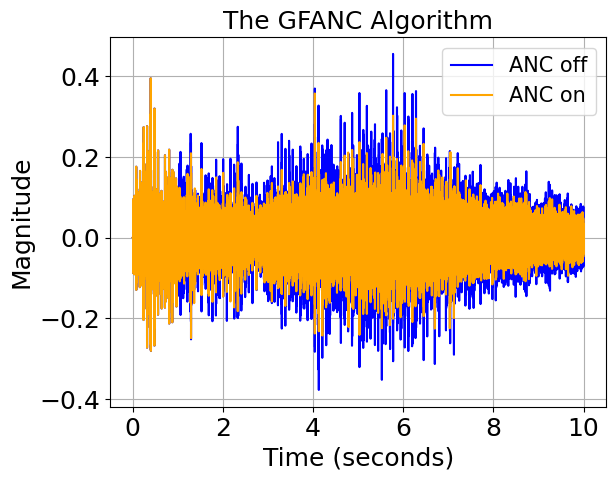

In [71]:
# GFANC: combining previous and present frame to predict the next

MODEL_PTH = 'models_from_original_dataset/datasize_delay'+str(delay)+'.pth'
path_mat = 'models/Pretrained_Sub_Control_filters_delay_'+str(delay)+'.mat' 
# MODEL_PTH = "models_from_original_dataset/M6_res_Synthetic.pth"
# path_mat = 'models/Pretrained_Sub_Control_filters.mat'
# Noisy_Fx = additional_noise(Fx, 20)
# prediction index
Filter_vector = Control_filter_selection_pre_now(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
ErrorFixed = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

Time = np.arange(len(Dis))*(1/fs)
plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

plt.title('The GFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorFixed, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig(sound_name + '/GFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
import torchaudio
filePath = "Err/" + "gfanc_" + sound_name + "_Err.wav"
noise = ErrorFixed.unsqueeze(0)
fs=16000
# noise = torch.from_numpy(noise).type(torch.float32).unsqueeze(0) # generate a random noise with the freqency limits
torchaudio.save(filePath, noise, fs)

In [ ]:
# # GFANC: present frame to predict the next

# MODEL_PTH = 'models1/M6_res_Synthetic.pth'
# path_mat = 'models/Pretrained_Sub_Control_filters.mat'

# # prediction index
# Filter_vector = Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

# Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
# ErrorFixed2 = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

# Time = np.arange(len(Dis))*(1/fs)
# plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
# plt.rc('axes', titlesize=18) # fontsize of the axes title
# plt.rc('axes', labelsize=18) # fontsize of the x and y labels
# plt.rc('xtick', labelsize=18) # fontsize of the tick labels
# plt.rc('ytick', labelsize=18) # fontsize of the tick labels
# plt.rc('legend', fontsize=15) # legend fontsize
# plt.rc('figure', titlesize=18) # fontsize of the figure title

# plt.title('(b) The GFANC Algorithm 2')
# plt.plot(Time, Dis, color='blue', label='ANC off')
# plt.plot(Time, ErrorFixed2, color='orange', label='ANC on')
# plt.ylabel('Magnitude')
# plt.xlabel('Time (seconds)')
# plt.legend()
# plt.grid()
# plt.savefig('GFANC2.png', dpi=600, bbox_inches='tight', pad_inches=0)
# plt.show()

In [ ]:
# Combine SFANC with FxNLMS
from Combine_SFANC_with_FxNLMS import SFANC_FxNLMS
from Control_filter_selectionSFANC import Control_filter_selectionSFANC
# prediction index
id_vector = Control_filter_selectionSFANC(fs=16000, Primary_noise=Re.unsqueeze(0)) # Primary_noise: torch.Size([1, XX])
print(id_vector)

# Using prediction index in SFANC_FxNLMS
FILE_NAME_PATH = 'models/SFANC_Pretrained_Control_filters.mat'
SFANC_FxNLMS_Cancellation = SFANC_FxNLMS(MAT_FILE=FILE_NAME_PATH, fs=16000)
Error_SFANC_FxNLMS = SFANC_FxNLMS_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx, filter_index=id_vector, Stepsize=0)

plt.title('The SFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, Error_SFANC_FxNLMS, color='red', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig(sound_name + '/SFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

The primary nosie has 20 seconds !!!
[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]


/home/rkobayashi/anc/GFANC-Generative-fixed-filter-active-noise-control/Hard_Label/3.Noise_Cancellation_Code/Combine_SFANC_with_FxNLMS.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.Wc = torch.tensor(Ws, requires_grad=True) # Ws: initial coefficients determined by SFANC


0
change the initial weights of FxNLMS
1
2


KeyboardInterrupt: 

[========================================================================] 100%
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
fi

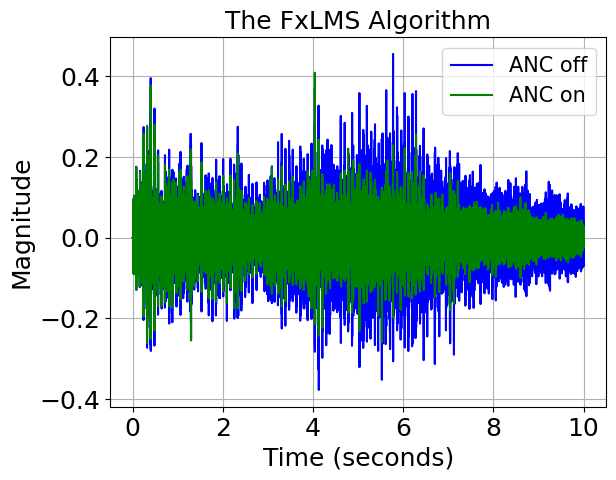

In [47]:
# FxLMS

controller = FxLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
ErrorFxLMS = train_fxlms_algorithm(Model=controller, Ref=Fx, Disturbance=Dis, Stepsize=StepSize) # torch.Size([320000])
Time = np.arange(len(Dis))*(1/fs)
plt.title('The FxLMS Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig(sound_name + '/FxLMS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

AttributeError: 'list' object has no attribute 'shape'

ValueError: x and y must have same first dimension, but have shapes (320000,) and (208000,)

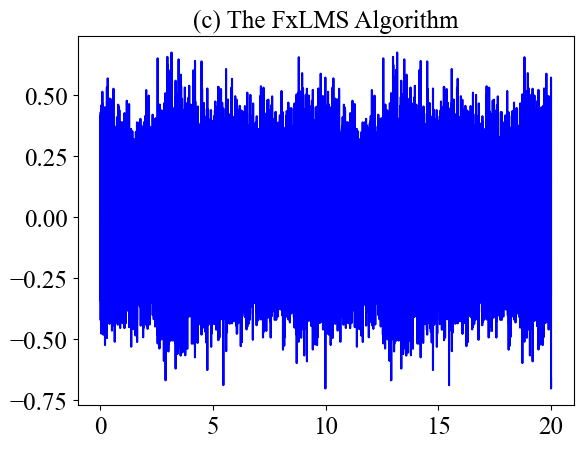

In [ ]:
Error_SFANC_FxNLMS_ = torchaudio.load("Err/noise_after_sfanc-fxnlms.wav")
Error_SFANC_FxNLMS_ = Error_SFANC_FxNLMS_[0][0, :].tolist()
plt.title('(c) The FxLMS Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, Error_SFANC_FxNLMS_, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()

plt.show()

In [ ]:
# compare the Noise_Reduction_Level in every second

def Noise_Reduction_Level_Compute(Disturbance, Error):
    Power_dis = 10*np.log10(np.var(Disturbance))
    Power_err = 10*np.log10(np.var(Error))
    NR_level = Power_dis - Power_err
    return NR_level

if torch.is_tensor(Dis):
    Dis = Dis.numpy() # tensor to numpy
if torch.is_tensor(ErrorFixed):
    ErrorFixed = ErrorFixed.numpy()
# if torch.is_tensor(ErrorFixed2):
#     ErrorFixed2 = ErrorFixed2.numpy()

a, b, c, d = [], [], [], []
a.append(Dis[0])
b.append(Dis[0])
c.append(Dis[0])
d.append(Dis[0])
Time1 = int(len(Dis)/fs)
for t in range(Time1):
    a.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFixed[t*fs:(t+1)*fs]))
    # b.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], Error_SFANC_FxNLMS[t*fs:(t+1)*fs]))
    c.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFxLMS[t*fs:(t+1)*fs]))
    # d.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], Error_SFANC_FxNLMS_[t*fs:(t+1)*fs]))
    
plt.title('(d) Averaged Noise Reduction Level of Every 1s')

plt.step(range(0,Time1+1), c, color='green', label='FxLMS')
# plt.step(range(0,Time1+1), b, color='blue', label='SFANC')
# plt.step(range(0,Time1+1), d, color="purple", label="SFANC-FxLMS")
plt.step(range(0,Time1+1), a, color='red', label='GFANC')
plt.ylabel('Noise Reduction Level (dB)')
plt.xlabel('Time (seconds)')
plt.xticks(range(0, Time1+1, 2)) # the interval in x
plt.legend()
plt.grid()
plt.savefig('Noise_Reduction_Level_Aircraft_Traffic_mix.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

NameError: name 'ErrorFxLMS' is not defined

In [ ]:
def plot_specgram(waveform, sample_rate, filepath, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f'Channel {c+1}')
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    plt.savefig(filepath)
    plt.close('all')

In [ ]:
spec_dis = torch.tensor(ErrorFixed).unsqueeze(0)
filepath = "spec/" + sound_name
plot_specgram(spec_dis, sample_rate=fs, filepath=filepath, title=("Spectrogram err "+ sound_name))

/tmp/ipykernel_1130819/2423939123.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spec_dis = torch.tensor(ErrorFixed).unsqueeze(0)
